# Tutorial 1: ISO-IR irrep labels on a phonopy dispersion

**For:** phonopy users who have a `FORCE_SETS` (or `FORCE_CONSTANTS`) and want to know which irreducible representation each phonon mode belongs to.
**Time:** about 10 minutes.
**Requirements:** CrystOD >= 0.4.0 (`pip install CrystOD`), which installs phonopy and matplotlib. No PySCF is needed.

What this notebook does:

1. builds a phonopy object of cubic SrTiO3 from the force sets bundled with CrystOD,
2. labels the degenerate levels at one q point with `crystod.phonon.label_phonon_modes` and reads the fields of a `PhononMode`,
3. shows that a non-representative arm of a star is mapped onto the tabulated q point,
4. draws the dispersion along the seekpath path with matplotlib and writes the ISO-IR labels at GM, X, M and R,
5. runs the command-line form, `crystod-phonon --irreps`, and reads the `phonon_irreps.yaml` it writes.

In [1]:
import crystod

crystod.__version__   # 0.4.0 or later is required

'0.4.0'

In [2]:
import os
import tempfile

workdir = tempfile.mkdtemp(prefix="crystod_tutorial_")
os.chdir(workdir)   # everything this notebook writes lands here, not next to the notebook
workdir

'/var/folders/z9/fy920zrj7jqf_3c45v8_s9400000gn/T/crystod_tutorial_9glpnhnz'

## Load the phonons

The input is the one every phonopy user has: a unit cell and the force sets of a supercell calculation. CrystOD ships cubic SrTiO3 (Pm-3m, 5 atoms) with the force sets of a 4x4x4 supercell as bundled example files; `crystod.examples.example_path` returns their absolute paths inside the installed package, so nothing has to be cloned.

Build the phonopy object with `primitive_matrix="auto"`. The irrep tables are indexed by the q points of the *primitive* cell; with an identity primitive matrix a zone-boundary mode of a non-primitive input cell would fold onto the supercell Gamma point, where it cannot be labeled with an irrep of the parent space group.

In [3]:
import phonopy
from crystod.examples import example_path

ph = phonopy.load(
    supercell_matrix=[4, 4, 4],
    primitive_matrix="auto",
    unitcell_filename=example_path("221_PPOSCAR_SrTiO3"),
    force_sets_filename=example_path("FORCE_SETS_SrTiO3"),
)
print(ph.primitive_symmetry.dataset.international, "-", len(ph.primitive), "atoms in the primitive cell,",
      3 * len(ph.primitive), "phonon branches")

Pm-3m - 5 atoms in the primitive cell, 15 phonon branches


## Label the modes at one q point

At a q point the phonon modes transform as irreducible representations of the little group of q. At R = (1/2, 1/2, 1/2), the corner of the cubic Brillouin zone, the little group is the full point group m-3m, so the 15 branches fall into degenerate levels of dimension 1, 2 or 3, each carrying one irrep. `label_phonon_modes` diagonalizes the dynamical matrix, groups the bands into degenerate levels, and names each level with its ISO-IR label (the Miller-Love convention used by ISOTROPY, ISODISTORT and the Bilbao Crystallographic Server).

The lowest level is imaginary: the `R5-` triplet is the antiphase rotation of the TiO6 octahedra, the antiferrodistortive instability that takes SrTiO3 from Pm-3m to I4/mcm at 105 K.

In [4]:
from crystod.phonon import label_phonon_modes

modes = label_phonon_modes(ph, [0.5, 0.5, 0.5])
for mode in modes:
    print(mode)

modes 1,2,3: -1.0867 THz  R5-
modes 4,5,6: 3.9891 THz  R4-
modes 7,8,9: 11.6887 THz  R5+
modes 10,11,12: 12.6621 THz  R4-
modes 13,14: 14.8133 THz  R3-
modes 15: 23.2302 THz  R2-


Each entry is a `PhononMode`. `band_indices` are 1-based, as in every CrystOD output (and in phonopy's `band.yaml`), `frequency` is in THz with a negative sign for an imaginary mode, `labels` holds the irrep label(s) without the dimension suffix that `phonon_irreps.yaml` appends, `qpoint` is the q point you asked for and `qpoint_label` the name of its star. `degeneracy` and `is_imaginary` are derived properties.

In [5]:
soft = modes[0]
{
    "band_indices": soft.band_indices,
    "frequency (THz)": round(soft.frequency, 4),
    "labels": soft.labels,
    "qpoint": soft.qpoint,
    "qpoint_label": soft.qpoint_label,
    "degeneracy": soft.degeneracy,
    "is_imaginary": soft.is_imaginary,
}

{'band_indices': (1, 2, 3),
 'frequency (THz)': -1.0867,
 'labels': ('R5-',),
 'qpoint': (0.5, 0.5, 0.5),
 'qpoint_label': 'R',
 'degeneracy': 3,
 'is_imaginary': True}

## A non-representative arm of the star

The tables list one representative q point per star. All arms of a star have the same spectrum band by band, so a q point given as another arm is mapped onto the tabulated one before labeling: (-1/2, 1/2, 1/2) is labeled `R`, and (1/2, 0, 0) is labeled `X` although the tables use (0, 1/2, 0). `representative_q` tells which arm the labels were taken from.

In [6]:
for q in ([-0.5, 0.5, 0.5], [0.5, 0.0, 0.0]):
    mode = label_phonon_modes(ph, q)[0]
    print(f"q = {q}  ->  star {mode.qpoint_label}, tabulated arm {mode.representative_q}:  {mode}")

q = [-0.5, 0.5, 0.5]  ->  star R, tabulated arm (0.5, 0.5, 0.5):  modes 1,2,3: -1.0867 THz  R5-
q = [0.5, 0.0, 0.0]  ->  star X, tabulated arm (0.0, 0.5, 0.0):  modes 1,2: 3.1516 THz  X5-


## All four special points

Pm-3m has four special q points, GM, X, M and R. Labeling all of them is what `crystod-phonon --irreps` writes to `phonon_irreps.yaml`; here the same information is kept in a dictionary for the plot below. Each entry reads `irrep(degeneracy) frequency`.

In [7]:
special_points = {"GM": [0, 0, 0], "X": [0, 0.5, 0], "M": [0.5, 0.5, 0], "R": [0.5, 0.5, 0.5]}
levels = {name: label_phonon_modes(ph, q) for name, q in special_points.items()}

for name, q in special_points.items():
    summary = "  ".join(f"{'+'.join(m.labels)}({m.degeneracy}) {m.frequency:.2f}" for m in levels[name])
    print(f"{name} {q}")
    print(f"    {summary}")

GM [0, 0, 0]
    GM4-(3) 0.00  GM4-(3) 2.66  GM4-(3) 4.71  GM5-(3) 7.35  GM4-(3) 15.31
X [0, 0.5, 0]
    X5-(2) 3.15  X5+(2) 3.79  X3-(1) 4.69  X5+(2) 5.38  X2+(1) 7.84  X1+(1) 7.85  X5-(2) 9.04  X1+(1) 13.82  X5+(2) 14.23  X3-(1) 21.25
M [0.5, 0.5, 0]
    M2+(1) 1.72  M3-(1) 3.07  M5-(2) 3.36  M2-(1) 3.50  M5-(2) 7.45  M5+(2) 9.22  M2-(1) 12.74  M5-(2) 12.86  M1+(1) 13.13  M3+(1) 14.94  M4+(1) 22.42
R [0.5, 0.5, 0.5]
    R5-(3) -1.09  R4-(3) 3.99  R5+(3) 11.69  R4-(3) 12.66  R3-(2) 14.81  R2-(1) 23.23


## The dispersion with irrep labels

`ph.auto_band_structure(plot=False)` runs the band structure along the seekpath path of the space group (GM-X-M-GM-R-X | M-R for Pm-3m) and leaves the result in `ph.band_structure`: one array of path distances and one of frequencies per segment, the segment end labels, and `path_connections`, which says where the path is broken. The irrep labels are written at the first occurrence of each special point; levels closer than 0.8 THz share one text.

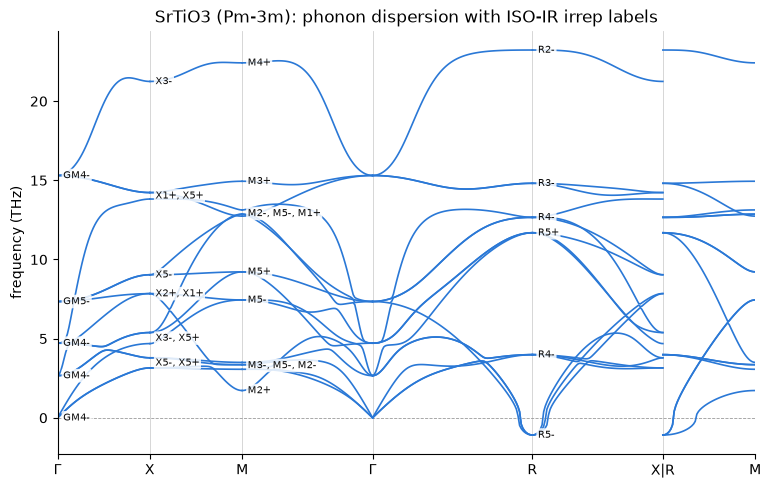

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

ph.auto_band_structure(plot=False)
band = ph.band_structure

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=100)
for distance, frequency in zip(band.distances, band.frequencies):
    ax.plot(distance, frequency, color="#2a78d6", lw=1.2)

# ticks at the segment ends; a broken path shows both labels ("X|R")
ticks, names, k = [band.distances[0][0]], [band.labels[0]], 1
for i, (distance, connected) in enumerate(zip(band.distances, band.path_connections)):
    ticks.append(distance[-1])
    if connected or i == len(band.distances) - 1:
        names.append(band.labels[k])
        k += 1
    else:
        names.append(band.labels[k] + "|" + band.labels[k + 1])
        k += 2
ax.set_xticks(ticks, names)
for x in ticks:
    ax.axvline(x, color="#d0d0d0", lw=0.6, zorder=0)
ax.axhline(0, color="#9a9a9a", lw=0.6, ls="--", zorder=0)

# first position of every special point along the path (q compared modulo reciprocal-lattice vectors)
first_x = {}
for distance, qpoints in zip(band.distances, band.qpoints):
    for x, q in ((distance[0], qpoints[0]), (distance[-1], qpoints[-1])):
        for name, q_special in special_points.items():
            wrapped = np.mod(np.asarray(q) - np.asarray(q_special) + 0.5, 1.0) - 0.5
            if name not in first_x and np.allclose(wrapped, 0.0, atol=1e-6):
                first_x[name] = x

for name, x in first_x.items():
    groups = []
    for mode in levels[name]:
        if groups and mode.frequency - groups[-1][-1].frequency < 0.8:
            groups[-1].append(mode)
        else:
            groups.append([mode])
    for group in groups:
        text = ", ".join("+".join(m.labels) for m in group)
        y = np.mean([m.frequency for m in group])
        ax.annotate(text, (x, y), xytext=(4, 0), textcoords="offset points", fontsize=7.5, va="center",
                    color="#0b0b0b", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

ax.set_xlim(ticks[0], ticks[-1])
ax.set_ylabel("frequency (THz)")
ax.set_title("SrTiO3 (Pm-3m): phonon dispersion with ISO-IR irrep labels")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

The imaginary `R5-` level at R and the acoustic `GM4-` triplet at zero frequency are the two features to read first. The labels at a special point are exactly the ones a Raman or infrared selection-rule table needs: at GM, `GM4-` is infrared active (it transforms like a vector), and the silent `GM5-` triplet is the one optical level that is neither Raman nor infrared active in a cubic perovskite.

## The command line: `crystod-phonon --irreps`

`crystod-phonon --irreps --dim 4 4 4 -c 221_PPOSCAR_SrTiO3` labels the same four special points and writes `phonon_irreps.yaml`; it reads `FORCE_SETS` from the working directory, as phonopy does. `crystod-phonon --example SrTiO3` copies the two bundled files into the current directory, prints that command line, and runs it. Here it is run through `subprocess` in the temporary directory (`python -m crystod.cli.phonon` is the same entry point as the `crystod-phonon` console script).

In [9]:
import subprocess
import sys

crystod_phonon = [sys.executable, "-m", "crystod.cli.phonon"]   # == the crystod-phonon console script
run = subprocess.run(crystod_phonon + ["--example", "SrTiO3"], cwd=workdir, capture_output=True, text=True, check=True)
print(run.stdout)
print(sorted(os.listdir(workdir)))

Wrote 221_PPOSCAR_SrTiO3 (bundled example input)
Wrote FORCE_SETS (bundled example input)
Running: crystod-phonon --irreps --dim '4 4 4' -c 221_PPOSCAR_SrTiO3

Phonon irreps written to: phonon_irreps.yaml

['221_PPOSCAR_SrTiO3', 'FORCE_SETS', 'phonon_irreps.yaml']


The YAML lists, for every special q point, the levels with their band indices (the `# 1 2 3` comments, 1-based), ISO-IR labels with the dimension in parentheses, and frequencies in THz. A level can be fed straight back into `crystod-phonon --vector --mode` (eigenvectors as VESTA arrows) or `--modulation --mode` (distorted structures).

In [10]:
from pathlib import Path

print("\n".join(Path("phonon_irreps.yaml").read_text().splitlines()[:36]))

space_group: Pm-3m
special_points:
- # GM
  q_position: [0.0, 0.0, 0.0]
- # R
  q_position: [0.5, 0.5, 0.5]
- # X
  q_position: [0.0, 0.5, 0.0]
- # M
  q_position: [0.5, 0.5, 0.0]

irreps:
- q_label: GM
  q_position: [0.0, 0.0, 0.0]
  - # 1 2 3
    irrep_label: ['GM4-(3)']
    frequency:   0.0000003685
  - # 4 5 6
    irrep_label: ['GM4-(3)']
    frequency:   2.6629186664
  - # 7 8 9
    irrep_label: ['GM4-(3)']
    frequency:   4.7144147359
  - # 10 11 12
    irrep_label: ['GM5-(3)']
    frequency:   7.3464877515
  - # 13 14 15
    irrep_label: ['GM4-(3)']
    frequency:  15.3054117938

- q_label: R
  q_position: [0.5, 0.5, 0.5]
  - # 1 2 3
    irrep_label: ['R5-(3)']
    frequency:  -1.0867090338
  - # 4 5 6


## Where next

- [21. Phonon irreps](https://mochizuki-tus.github.io/CrystOD/crystod-phonon.html#phonon-irreps-irreps) in the manual: `--all-irreps` also labels the symmetry lines of the seekpath path (DT, Z, SM, ...), `--readfc` reads `FORCE_CONSTANTS`, and the neighbouring sections cover `--fatband`, `--lt` and `--vector`.
- [Python API](https://mochizuki-tus.github.io/CrystOD/python-api.html): everything `crystod.phonon` exports, and the `ValueError`/`RuntimeError` conventions of the API.
- Tutorial 2, `02_isotropy_subgroup_search.ipynb`: which space groups the imaginary `R5-` mode found here can condense into, and how to generate the distorted structures.
- The theory of the labels: [Theoretical background](https://mochizuki-tus.github.io/CrystOD/theory-representations.html).